In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import cv2
from glob import glob
import itertools
import os

In [2]:
from keras.utils import np_utils
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers import BatchNormalization
from keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,CSVLogger

Using TensorFlow backend.


In [0]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [0]:
from tensorflow.python.framework import ops
ops.reset_default_graph()

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


In [0]:
%matplotlib inline
plt.rcParams['figure.figsize'] = [16, 10]
plt.rcParams['font.size'] = 16

In [7]:
#List of Classes/Labels
os.listdir("/content/drive/My Drive/AIML/CNN/Project1/input/train")

['Sugar beet',
 'Maize',
 'Loose Silky-bent',
 'Scentless Mayweed',
 'Small-flowered Cranesbill',
 'Shepherds Purse',
 'Common wheat',
 'Common Chickweed',
 'Fat Hen',
 'Cleavers',
 'Charlock',
 'Black-grass']

In [0]:
train = "/content/drive/My Drive/AIML/CNN/Project1/input/train/*/*.png"
test = "/content/drive/My Drive/AIML/CNN/Project1/input/test/*.png"

In [0]:
train_files = glob(train)
test_files = glob(test)

## Read the images and generate the train and test dataset

In [0]:
train_images = []
train_label = []
for img in train_files:
    images=cv2.imread(img)
    train_images.append(cv2.resize(images, (70,70,)))
    train_label.append(img.split('/')[-2])

train_images = np.asarray(train_images)
train_label = pd.DataFrame(train_label)

In [14]:
print("The shape of train images is:",train_images.shape)
print(("The shape of train labels is:",train_label.shape))

The shape of train images is: (4750, 70, 70, 3)
('The shape of train labels is:', (4750, 1))


In [0]:
test_images = []
test_label = []
for img in test_files:
    images=cv2.imread(img)
    test_images.append(cv2.resize(images, (70,70,)))
    test_label.append(img.split('/')[-2])

test_images = np.asarray(test_images)
test_label = pd.DataFrame(test_label)

In [12]:
print("The shape of test images is:",test_images.shape)
print(("The shape of test labels is:",test_label.shape))

The shape of test images is: (794, 70, 70, 3)
('The shape of test labels is:', (794, 1))


(1023, 1023, 3) (70, 70, 3)


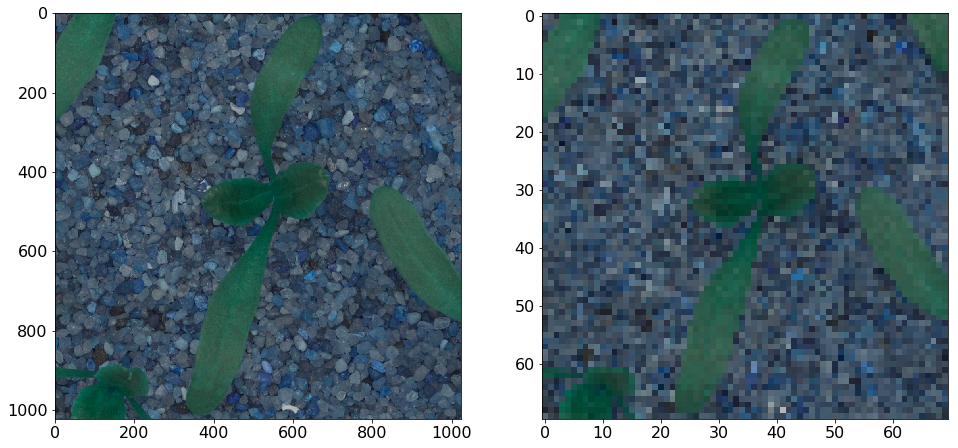

In [15]:
#View one sample image
sample_image_scale = train_images[1]
sample_image_orig = cv2.imread(train_files[1])
print(sample_image_orig.shape, sample_image_scale.shape)
plt.subplot(1,2,1)
plt.imshow(sample_image_orig)
plt.subplot(1,2,2)
plt.imshow(sample_image_scale)

In [0]:
train_images = train_images/255

In [17]:
label_encoder = preprocessing.LabelEncoder()
label_encoder.fit(train_label[0])
encoded_train_labels = label_encoder.transform(train_label[0])
encoded_labels = np_utils.to_categorical(encoded_train_labels)
classes = encoded_labels.shape[0]
print('Classes'+str(label_encoder.classes_))
print(str(classes))

Classes['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
4750


#### Divide the data set into Train and validation data sets

In [0]:
X_train, X_val, y_train, y_val = train_test_split(train_images, encoded_labels, test_size=0.1, random_state=7, stratify = encoded_labels)

## Initialize & build the model

In [0]:
model = Sequential()
model.add(Conv2D(32,(3, 3), input_shape=(70,70,3),activation= 'relu'))
model.add(Conv2D(32,(3, 3),activation= 'relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(512, activation= 'relu'))
model.add(Dense(12, activation='softmax'))

In [0]:
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [30]:
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 68, 68, 32)        896       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 66, 66, 32)        9248      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 33, 33, 32)        0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 34848)             0         
_________________________________________________________________
dense_3 (Dense)              (None, 512)               17842688  
_________________________________________________________________
dense_4 (Dense)              (None, 12)                6156      
Total params: 17,858,988
Trainable params: 17,858,988
Non-trainable params: 0
__________________________________________

In [31]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs= 10, batch_size=10)

Train on 4275 samples, validate on 475 samples
Epoch 1/10
4275/4275 [==============================] - 14s 3ms/step - loss: 2.0969 - acc: 0.3020 - val_loss: 1.6479 - val_acc: 0.4653
Epoch 2/10
4275/4275 [==============================] - 14s 3ms/step - loss: 1.1905 - acc: 0.6054 - val_loss: 1.1362 - val_acc: 0.6211
Epoch 3/10
4275/4275 [==============================] - 14s 3ms/step - loss: 0.8465 - acc: 0.7198 - val_loss: 1.1066 - val_acc: 0.6147
Epoch 4/10
4275/4275 [==============================] - 14s 3ms/step - loss: 0.5444 - acc: 0.8243 - val_loss: 0.9710 - val_acc: 0.6968
Epoch 5/10
4275/4275 [==============================] - 14s 3ms/step - loss: 0.3333 - acc: 0.8985 - val_loss: 1.0763 - val_acc: 0.6926
Epoch 6/10
4275/4275 [==============================] - 14s 3ms/step - loss: 0.1948 - acc: 0.9425 - val_loss: 1.2476 - val_acc: 0.6884
Epoch 7/10
4275/4275 [==============================] - 14s 3ms/step - loss: 0.1334 - acc: 0.9586 - val_loss: 1.6474 - val_acc: 0.6653
Epoch 8/

In [33]:
score = model.evaluate(X_train, y_train)
print("Model Accuracy with Training Data", score[1])

4275/4275 [==============================] - 1s 304us/step
Model Accuracy with Training Data 0.9988304093567252


In [35]:
score = model.evaluate(X_val, y_val)
print("Model Accuracy with Training Data", score[1])

475/475 [==============================] - 0s 470us/step
Model Accuracy with Training Data 0.7010526314534639


In [36]:
y_pred = model.predict(X_val)
y_class = np.argmax(y_pred, axis = 1) 
y_check = np.argmax(y_val, axis = 1) 

#Print confusion matrix
cmatrix = confusion_matrix(y_check, y_class)
print(cmatrix)

[[ 4  0  0  1  2  0 19  0  0  0  0  0]
 [ 0 32  2  0  0  0  0  0  1  2  2  0]
 [ 0  0 26  0  0  1  0  0  2  0  0  0]
 [ 0  0  0 49  0  1  0  2  1  2  4  2]
 [ 2  0  0  0  7  2  9  0  2  0  0  0]
 [ 1  1  1  2  1 32  2  1  1  1  3  1]
 [ 8  0  0  0  3  1 52  0  1  0  0  0]
 [ 0  0  0  1  0  1  0 16  2  2  0  0]
 [ 0  2  1  1  2  0  5  0 38  2  0  1]
 [ 0  0  0  2  0  1  0  2  3 14  1  0]
 [ 0  0  1  0  0  1  0  1  0  1 45  1]
 [ 2  0  2  1  1  7  1  1  2  1  3 18]]


## Optimize the model

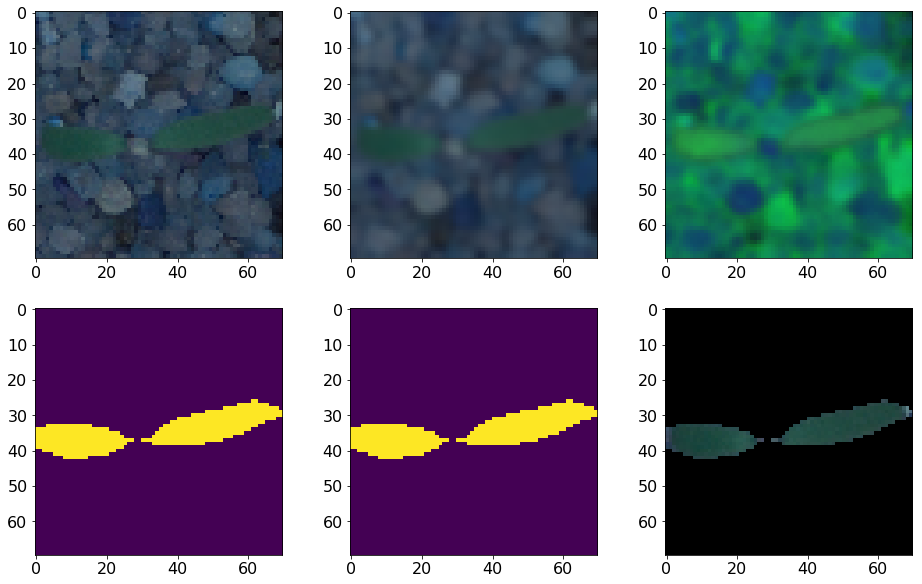

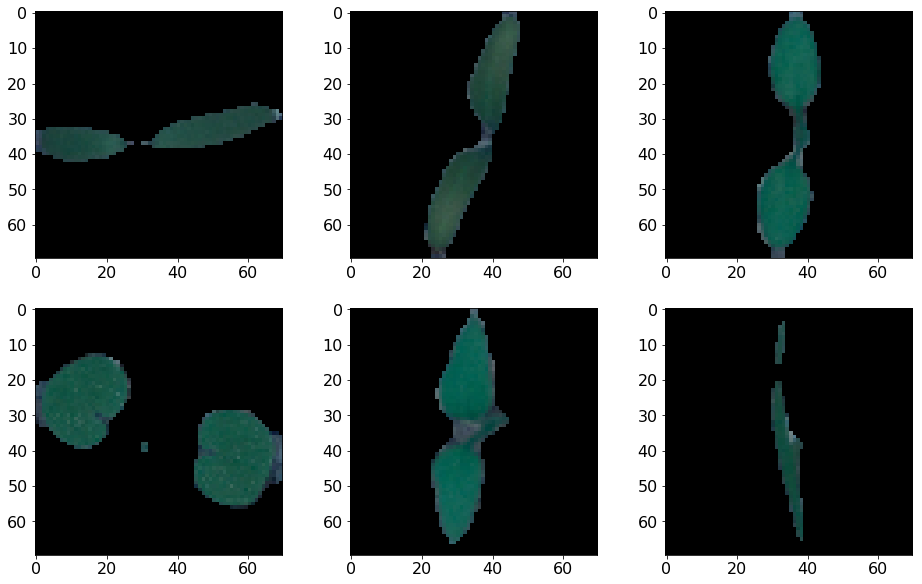

In [37]:
testimages = []
sets = []
getEx = True
for i in test_images:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    masking = np.zeros_like(i,np.uint8)
    masking[boolean] = i[boolean]
    testimages.append(masking)
    
    if getEx:
        plt.subplot(2,3,1);plt.imshow(i)
        plt.subplot(2,3,2);plt.imshow(blurr)
        plt.subplot(2,3,3);plt.imshow(hsv)
        plt.subplot(2,3,4);plt.imshow(mask)
        plt.subplot(2,3,5);plt.imshow(boolean)
        plt.subplot(2,3,6);plt.imshow(masking)
        plt.show()
        getEx=False

testimages = np.asarray(testimages)
# OTHER MASKED IMAGES
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(testimages[i])

In [0]:
model_new = Sequential()

model_new.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=(70, 70, 3), activation='relu'))
model_new.add(BatchNormalization(axis=3))
model_new.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model_new.add(MaxPooling2D((2, 2)))
model_new.add(BatchNormalization(axis=3))
model_new.add(Dropout(0.12))

model_new.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model_new.add(BatchNormalization(axis=3))
model_new.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model_new.add(MaxPooling2D((2, 2)))
model_new.add(BatchNormalization(axis=3))
model_new.add(Dropout(0.12))

model_new.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
model_new.add(BatchNormalization(axis=3))
model_new.add(Conv2D(filters=256, kernel_size=(3,3), activation='relu'))
model_new.add(MaxPooling2D((2, 2)))
model_new.add(BatchNormalization(axis=3))
model_new.add(Dropout(0.12))

model_new.add(Flatten())

model_new.add(Dense(256, activation='relu'))
model_new.add(BatchNormalization())
model_new.add(Dropout(0.25))

model_new.add(Dense(256, activation='relu'))
model_new.add(BatchNormalization())
model_new.add(Dropout(0.25))

model_new.add(Dense(256, activation='relu'))
model_new.add(BatchNormalization())
model_new.add(Dropout(0.25))

model_new.add(Dense(256, activation='relu'))
model_new.add(BatchNormalization())
model_new.add(Dropout(0.25))

model_new.add(Dense(12, activation='softmax'))

In [48]:
print(model_new.summary())

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_11 (Conv2D)           (None, 68, 68, 64)        1792      
_________________________________________________________________
batch_normalization_11 (Batc (None, 68, 68, 64)        256       
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 66, 66, 64)        36928     
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 33, 33, 64)        0         
_________________________________________________________________
batch_normalization_12 (Batc (None, 33, 33, 64)        256       
_________________________________________________________________
dropout_8 (Dropout)          (None, 33, 33, 64)        0         
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 31, 31, 128)      

# Predict the accuracy for both train and validation data

In [0]:
model_new.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [50]:
model_new.fit(X_train, y_train, validation_data=(X_val, y_val), epochs= 10, batch_size=100)

Train on 4275 samples, validate on 475 samples
Epoch 1/10
4275/4275 [==============================] - 13s 3ms/step - loss: 2.0713 - acc: 0.3619 - val_loss: 2.8897 - val_acc: 0.4021
Epoch 2/10
4275/4275 [==============================] - 10s 2ms/step - loss: 1.2229 - acc: 0.6019 - val_loss: 1.8275 - val_acc: 0.5516
Epoch 3/10
4275/4275 [==============================] - 10s 2ms/step - loss: 0.9037 - acc: 0.6966 - val_loss: 1.4311 - val_acc: 0.6189
Epoch 4/10
4275/4275 [==============================] - 10s 2ms/step - loss: 0.7021 - acc: 0.7588 - val_loss: 1.3818 - val_acc: 0.6611
Epoch 5/10
4275/4275 [==============================] - 10s 2ms/step - loss: 0.5994 - acc: 0.7935 - val_loss: 1.9869 - val_acc: 0.5242
Epoch 6/10
4275/4275 [==============================] - 10s 2ms/step - loss: 0.5131 - acc: 0.8166 - val_loss: 1.1931 - val_acc: 0.6989
Epoch 7/10
4275/4275 [==============================] - 10s 2ms/step - loss: 0.4280 - acc: 0.8540 - val_loss: 1.7206 - val_acc: 0.6337
Epoch 8/

In [51]:
new_score_train = model_new.evaluate(X_train, y_train)
print("Best Model Accuracy with Training Data", new_score_train[1])

4275/4275 [==============================] - 4s 898us/step
Best Model Accuracy with Training Data 0.8694736843360098


In [52]:
new_score_val = model_new.evaluate(X_val, y_val)
print("Best Model Accuracy with Test Data", new_score_val[1])

475/475 [==============================] - 1s 1ms/step
Best Model Accuracy with Test Data 0.8021052626559609
